# Hurricane Milton — GWR / Moran's I (comparable pipeline)

**Unit of analysis:** 21 Florida counties (50-mi cut from the track).

Milton struck the Florida peninsula; the analysis units are the **21 counties** within 50 mi of the track (no clustering needed — the affected set is compact). **N = 21 is small for GWR**, so the local surfaces below are read as exploratory and the formal OLS-vs-GWR AICc gate is given more weight than any single local map.

**Pipeline (identical for both storms):** global OLS → Moran's I on residuals (the *should-we-GWR* gate) → Geographically Weighted Regression → matched maps and an OLS-vs-GWR model comparison.

> **Comparability.** This notebook and its sibling [`helene_gwr_compare.ipynb`](helene_gwr_compare.ipynb) (Hurricane Helene) run the **identical** pipeline from the shared module `gwr_compare_utils.py`: same pooled dataset, same four predictors (median HH income, %White, NCHS urban–rural code, distance-to-track), same two within-county DVs, same spatial weights, and **figures with matched colour scales and layouts** — so Fig _n_ here is directly comparable to Fig _n_ there. All outputs are written to `results/gwr_compare/milton/`.

In [1]:
%matplotlib inline
import importlib
import gwr_compare_utils as U
importlib.reload(U)               # pick up edits to the shared module
import pandas as pd
pd.set_option('display.width', 140)

HURR = 'milton'
print('Features :', U.FEATURES)
print('DVs      :', [d[1] for d in U.DVS])

Features : ['median_household_income', 'pct_white', 'nchs_code', 'dist_to_track_mi']
DVs      : ['Largest Drop — Within (%)', 'Recovery Time — Within (days)']


/Users/qing/miniconda3/envs/geo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## §1  Load data & reconstruct geometry
Pulls this storm's rows from `pooled_dataset.csv`, attaches the unit polygons (Helene: dissolve counties→clusters; Milton: the 21 counties), projects to Albers (EPSG:5070), and z-scores the predictors.

In [2]:
gdf, track = U.load_units(HURR)
g, X_z = U.prep_model(gdf)
print(f'Analysis units (non-missing): N = {len(g)}')
g[['NAME'] + U.FEATURES + [d[0] for d in U.DVS]].head()

Analysis units (non-missing): N = 21


,NAME,median_household_income,pct_white,nchs_code,dist_to_track_mi,largest_drop_within,recovery_days_within
0,Brevard,71308.0,80.919392,3.0,10.315948,-25.543581,4.616241
1,Charlotte,62164.0,88.951518,4.0,43.319139,-46.303099,4.061630
2,DeSoto,45000.0,81.903080,5.0,34.944728,-42.837819,2.499718
3,Hardee,44665.0,76.771377,6.0,18.407624,-26.062992,3.907675
4,Hernando,59202.0,86.631883,2.0,66.109596,-39.450492,5.396989


## §2  Global OLS baseline
One standardized OLS per DV. These coefficients are the *global* (stationary) story that GWR will test for spatial variation.

In [3]:
ols = U.run_ols(g, X_z)
U.ols_table(ols)

,dv,term,beta,p,R2,adjR2
0,Largest Drop — Within (%),const,-32.013,0.0000,0.13,-0.087
1,Largest Drop — Within (%),median_household_income,2.158,0.4567,0.13,-0.087
2,Largest Drop — Within (%),pct_white,-2.324,0.3827,0.13,-0.087
3,Largest Drop — Within (%),nchs_code,2.719,0.3949,0.13,-0.087
4,Largest Drop — Within (%),dist_to_track_mi,-1.012,0.6634,0.13,-0.087
5,Recovery Time — Within (days),const,4.547,0.0000,0.20,-0.000
6,Recovery Time — Within (days),median_household_income,0.112,0.6658,0.20,-0.000
7,Recovery Time — Within (days),pct_white,0.104,0.6622,0.20,-0.000
8,Recovery Time — Within (days),nchs_code,-0.267,0.3549,0.20,-0.000
9,Recovery Time — Within (days),dist_to_track_mi,0.105,0.6165,0.20,-0.000


## §3  Spatial diagnostics — the Moran's I gate
Moran's I on the OLS residuals (Queen contiguity **and** KNN k=4). Significant positive I ⇒ the global model leaves spatially-clustered error ⇒ GWR may help. The residual maps show *where* the global model over- (red) / under- (blue) predicts.

In [4]:
diag, weights = U.spatial_diagnostics(g, ols)
print('PROCEED_GWR (any residual Moran p < 0.10):', bool(diag['proceed_gwr'].iloc[0]))
diag

PROCEED_GWR (any residual Moran p < 0.10): True


,dv,test,I,p,proceed_gwr
0,Largest Drop — Within (%),Moran_Queen,0.1938,0.046,True
1,Largest Drop — Within (%),Moran_KNN4,0.1308,0.105,True
2,Recovery Time — Within (days),Moran_Queen,-0.1689,0.182,True
3,Recovery Time — Within (days),Moran_KNN4,-0.1136,0.290,True


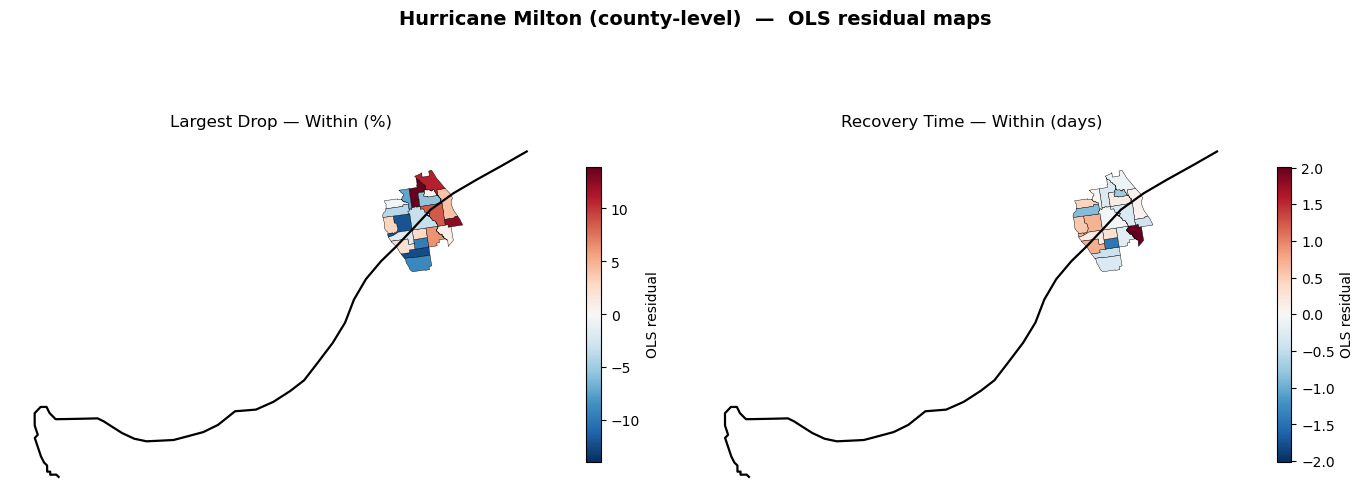

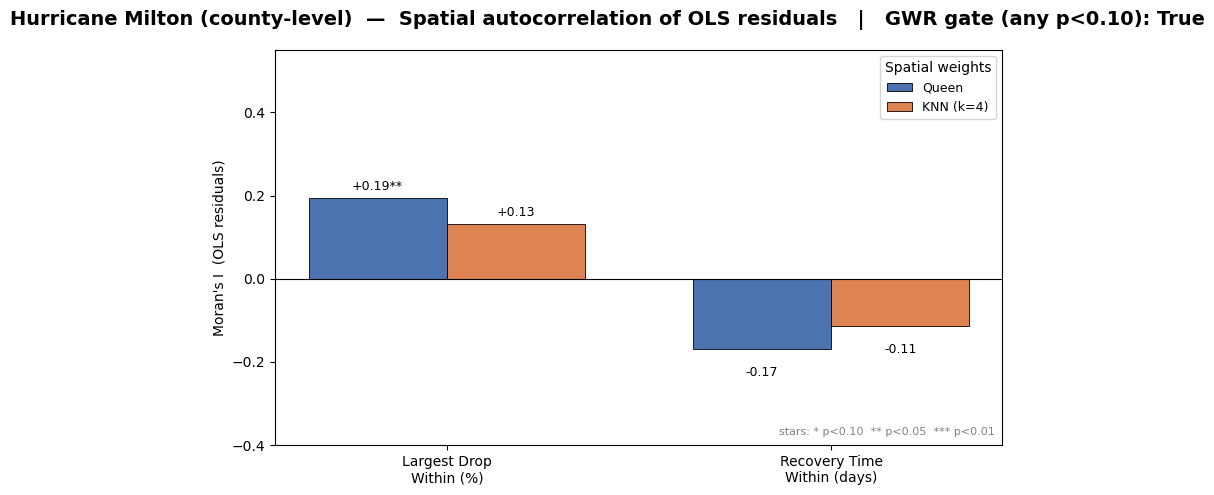

In [5]:
_ = U.plot_residual_maps(g, ols, track, HURR)      # Fig 1
_ = U.plot_morans(diag, HURR)                       # Fig 2

## §4  Geographically Weighted Regression
Adaptive bisquare kernel; bandwidth chosen by AICc. Bounds are set explicitly because mgwr's default lower bound (40 + 2·k) exceeds these small N.

In [6]:
gwr, bw_bounds = U.fit_gwr(g, X_z)
print('Bandwidth search bounds (k neighbours):', bw_bounds)
for dv, lab in U.DVS:
    r = gwr[dv]
    if r['ok']:
        m = r['model']
        print(f"  {lab:<32} bw={r['bw']:>4}  R2={m.R2:.3f}  adjR2={m.adj_R2:.3f}  "
              f"localR2=[{m.localR2.min():.2f}, {m.localR2.max():.2f}]")
    else:
        print(f'  {lab}: GWR failed -> {r.get("err")}')

Bandwidth search bounds (k neighbours): (8, 20)
  Largest Drop — Within (%)        bw=19.0  R2=0.544  adjR2=0.096  localR2=[0.22, 0.56]
  Recovery Time — Within (days)    bw=19.0  R2=0.531  adjR2=0.071  localR2=[0.25, 0.73]


## §5  GWR maps — local R² and per-predictor t-stats
Local R² (viridis, fixed 0–1) shows where the model explains local variance. The t-stat panels show where each predictor's *local* slope is significant (|t|>1.96); grey = not significant.

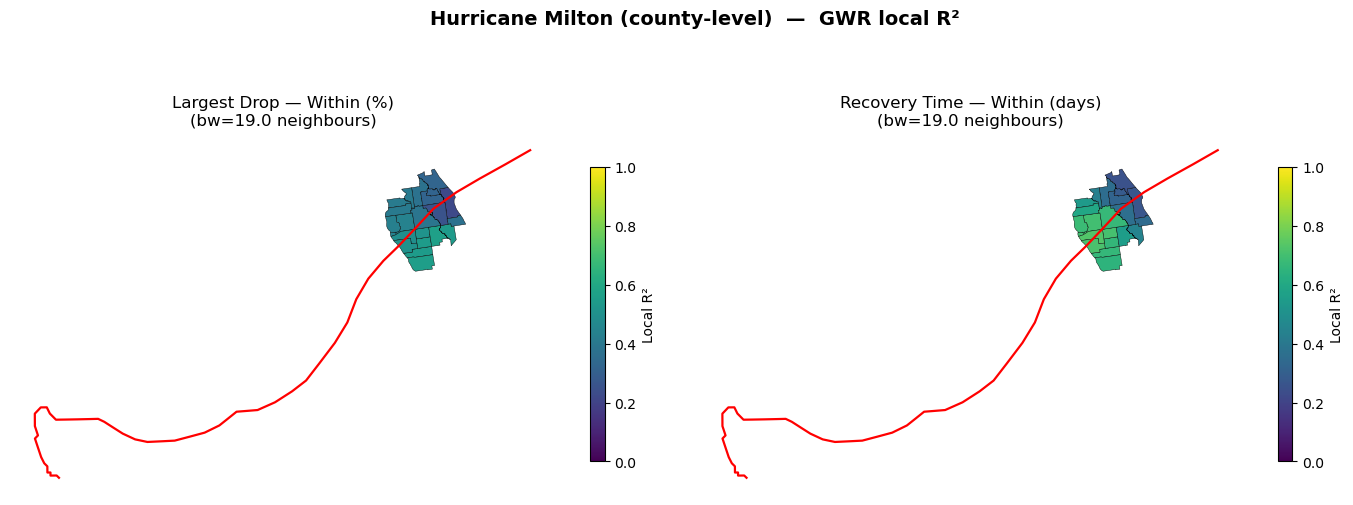

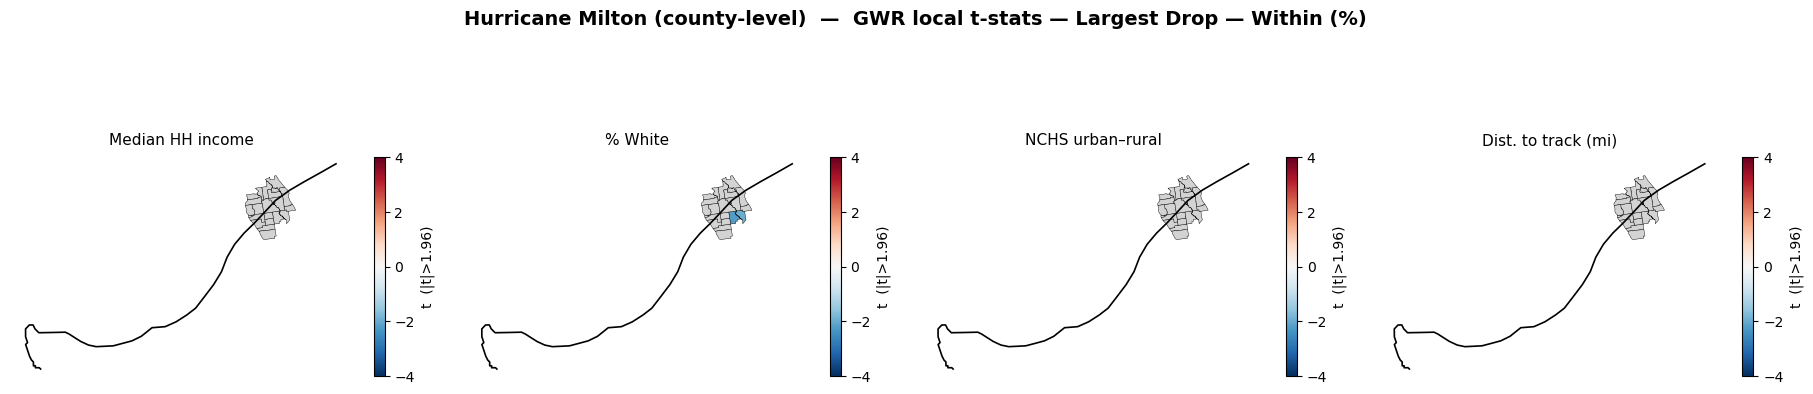

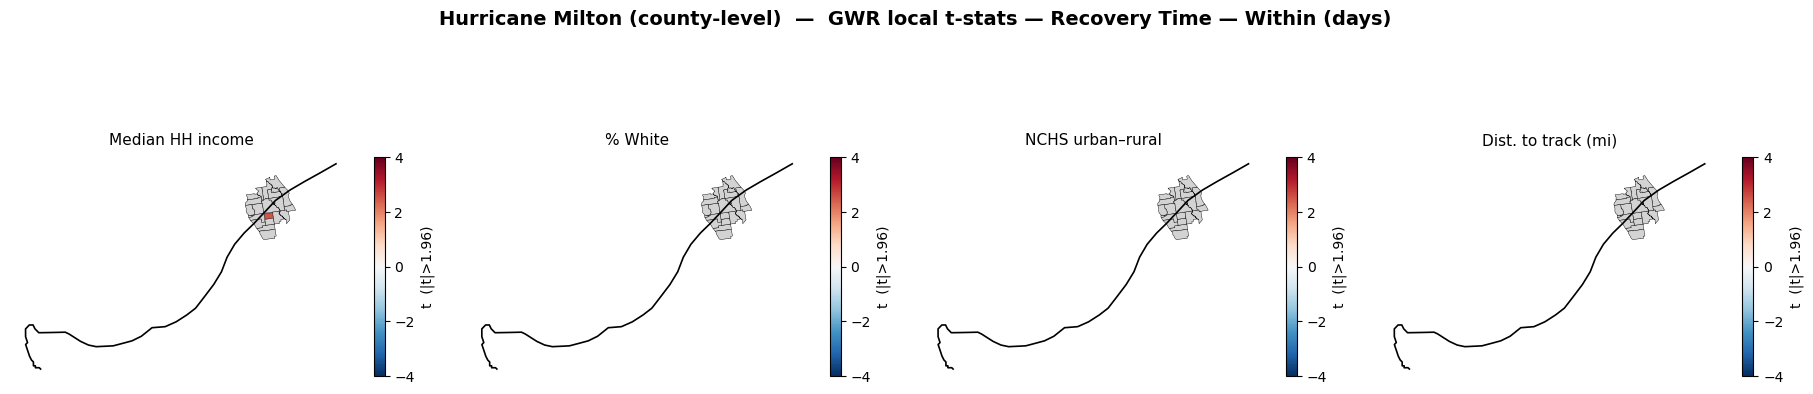

In [7]:
_ = U.plot_local_r2(g, gwr, track, HURR)            # Fig 3
for dv, lab in U.DVS:
    _ = U.plot_coef_tmaps(g, gwr, track, HURR, dv, lab)   # Fig 4 (one per DV)

## §6  OLS vs GWR — does the local model actually help?
AICc on a common scale (statsmodels full Gaussian AIC + small-sample correction, matching mgwr's `aicc`). Lower AICc wins; a negative `dAICc` means GWR beats OLS.

In [8]:
cmp = U.model_comparison(g, ols, gwr)
cmp

,dv,N,OLS_AICc,OLS_R2,OLS_adjR2,GWR_AICc,GWR_R2,GWR_adjR2,GWR_bw,dAICc
0,Largest Drop — Within (%),21,158.62,0.13,-0.087,181.47,0.544,0.096,19.0,22.85
1,Recovery Time — Within (days),21,57.60,0.20,-0.000,82.79,0.531,0.071,19.0,25.19


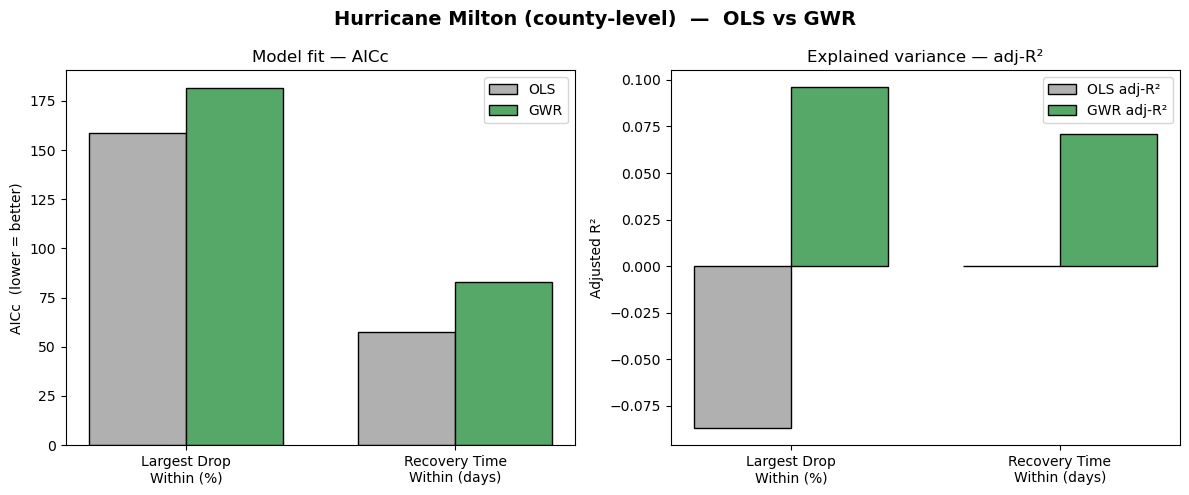

In [9]:
_ = U.plot_model_comparison(cmp, HURR)              # Fig 5

## §7  Interpretation

1. **Moran's I (Fig 2).** *Largest Drop* shows **significant positive** residual autocorrelation (Queen I = +0.19*, KNN I = +0.13*) — neighbouring counties are left over-/under-predicted *together*, i.e. the global model misses a real spatial structure in drop magnitude. Recovery-time residuals are not clustered.

2. **GWR vs OLS (Fig 5).** Despite the Moran signal, GWR's AICc is far *worse* than OLS for both DVs (ΔAICc ≈ +23 / +25). With only 21 units the bandwidth collapses to ~19 neighbours and the effective-parameter penalty dominates — GWR cannot be justified on fit. The local t-stat maps (Fig 4) are almost entirely |t|<1.96 (grey).

3. **Verdict.** There *is* spatial structure in the drop residuals (Moran's I), but the sample is too small to resolve it with GWR. The honest takeaway is a flag for an omitted spatial covariate (e.g. coastal storm-surge exposure), not a fitted local-coefficient surface.

---
*Figures saved to* `results/gwr_compare/milton/figures/` *(fig1–fig5). Compare against the [Helene notebook](helene_gwr_compare.ipynb) panel-for-panel.*